In [1]:
library("DESeq2")
library("ggplot2")
library("ggrepel")
library("ggcorrplot")
library(CCA)
library("dplyr")
library(stringr)
library(purrr)
library("tibble")
library(dplyr)
library(tidyr)
library(ComplexHeatmap)
library("pals")
library(ggpubr)
library(tximport)
library(DESeq2)
library("apeglm")
library(patchwork)
library(ggrastr)
library(circlize)
library(corrplot)
library(ggrepel)


theme_set(
    theme_classic(base_size = 12)
)
source('./plot_data.R')

Warning message:
“package ‘DESeq2’ was built under R version 4.2.3”
Loading required package: S4Vectors

Warning message:
“package ‘S4Vectors’ was built under R version 4.2.3”
Loading required package: stats4

Loading required package: BiocGenerics

Warning message:
“package ‘BiocGenerics’ was built under R version 4.2.1”

Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:base’:

    exp

In [190]:
final_iso_tb<- read.table("../data/2_final_iso_tb.tsv", sep = "\t", header = T)
gene_levels <- sort(unique(final_iso_tb$gene_id))
iso_levels = c("canonical", "downstream", "antisense")

de_mature<- read.table("../data/7_mature_rna_DE_results.tsv", sep = "\t")
de_nascent<- read.table("../data/7_nascent_rna_DE_results.tsv", sep = "\t")
non_sig_iso<- unique(sort(c(de_nascent %>% filter(labels == "Not sig") %>% pull(iso_id), 
                            de_mature %>% filter(labels == "Not sig") %>% pull(iso_id))))

In [195]:
df1<- de_nascent %>% 
    select(gene_id, feature_id, log2FoldChange) %>% 
    complete(gene_id = gene_levels, feature_id = iso_levels, fill = list(log2FoldChange = 0))

colnames(df1)<- c(colnames(df1)[1:2], paste0('nascent_', colnames(df1)[3]))

df2<- de_mature %>% 
    select(gene_id, feature_id, log2FoldChange) %>% 
    complete(gene_id = gene_levels, feature_id = iso_levels, fill = list(log2FoldChange = 0)) 

colnames(df2)<- c(colnames(df2)[1:2], paste0('mature_', colnames(df2)[3]))

# remove genes with 0 expression in both methods
df_merged<- merge(df1, df2) %>% 
    filter(!(mature_log2FoldChange == 0 & nascent_log2FoldChange ==0)) %>% 
    mutate(label = 
           case_when((mature_log2FoldChange>0 & nascent_log2FoldChange<0) ~ "low in nascent",
                     (mature_log2FoldChange<0 & nascent_log2FoldChange>0) ~ "high in nascent",
                     (mature_log2FoldChange*nascent_log2FoldChange == 0) ~ "missing",
                     TRUE ~ "same direction"))

df_merged$iso_id<- paste0(df_merged$gene_id, ":", df_merged$feature_id)
df_merged$label<- factor(df_merged$label, levels = c("missing", "low in nascent", "same direction", "high in nascent"))
# df_merged$new_label = as.character(df_merged$label)
# df_merged[df_merged$iso_id %in% non_sig_iso, "new_label"] = 'Not sig'
# table(df_merged$new_label)
# df_merged$new_label<- factor(df_merged$new_label, levels = c("Not sig", "missing", "low in nascent", "same direction", "high in nascent"))


match_colors<- c("grey", "#FDDFA4FF", "#60a0d5", "#4C6250", "#C2697FFF")
names(match_colors)<- c("Not sig", "missing", "low in nascent", "same direction", "high in nascent")

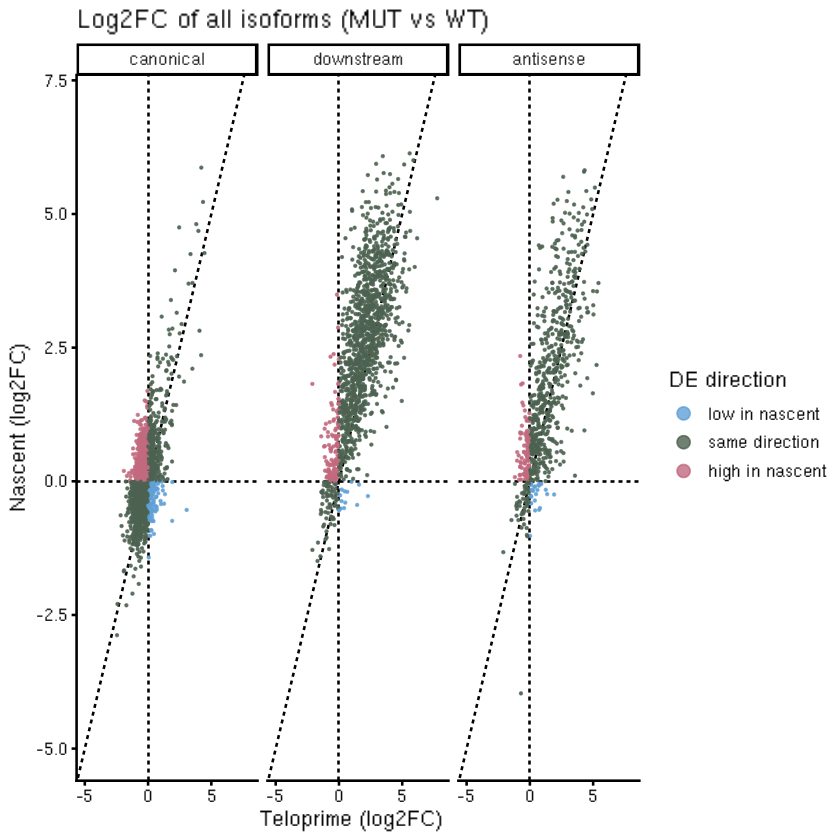

In [279]:
df_merged %>% 
    mutate(feature_id = factor(feature_id, levels = c("canonical", "downstream", "antisense"))) %>% 
    filter(label != 'missing') %>% 
    ggplot(aes(x = mature_log2FoldChange, y = nascent_log2FoldChange)) +
    geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "black") +
    geom_hline(yintercept = 0, linetype = "dashed", color = "black") +
    geom_vline(xintercept = 0, linetype = "dashed", color = "black") +    
    geom_point(aes(color = label), size = 0.1, alpha = 0.8) +
    labs(x = "Teloprime (log2FC)  ", y = "Nascent (log2FC)", title = "Log2FC of all isoforms (MUT vs WT)", 
     color  = 'DE direction') +
    xlim(-5, 8) + ylim(-5,7) +
    scale_color_manual(values = match_colors) +
    guides(color = guide_legend(override.aes = list(size = 3))) +
    facet_wrap(~feature_id, ncol = 3)

ggsave("../figures/Supp _correlation_log2fc_nascent_vs_mature_by_match_by_feature_id.pdf", width = 8, height = 3)

Warning message:
“Removed 2 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range (`geom_point()`).”


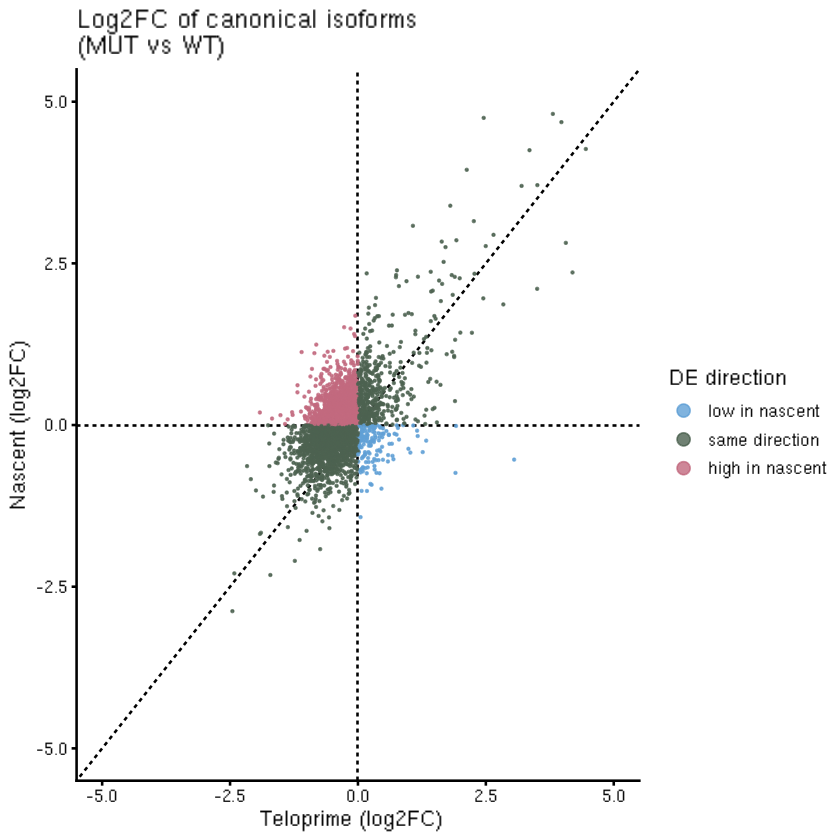

In [197]:
df_merged %>% 
    filter(label != 'missing', feature_id == 'canonical') %>% 
    ggplot(aes(x = mature_log2FoldChange, y = nascent_log2FoldChange)) +
    geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "black") +
    geom_hline(yintercept = 0, linetype = "dashed", color = "black") +
    geom_vline(xintercept = 0, linetype = "dashed", color = "black") +    
    geom_point(aes(color = label), size = 0.1, alpha = 0.8) +
    labs(x = "Teloprime (log2FC)  ", y = "Nascent (log2FC)", 
         title = "Log2FC of canonical isoforms\n(MUT vs WT)", 
         color  = 'DE direction') + 
    xlim(-5, 5) + ylim(-5,5) +
    scale_color_manual(values = match_colors) +
    guides(color = guide_legend(override.aes = list(size = 3)))

ggsave("../figures/12_correlation_log2fc_nascent_vs_mature_by_match_canonical.pdf", width = 5, height = 3)

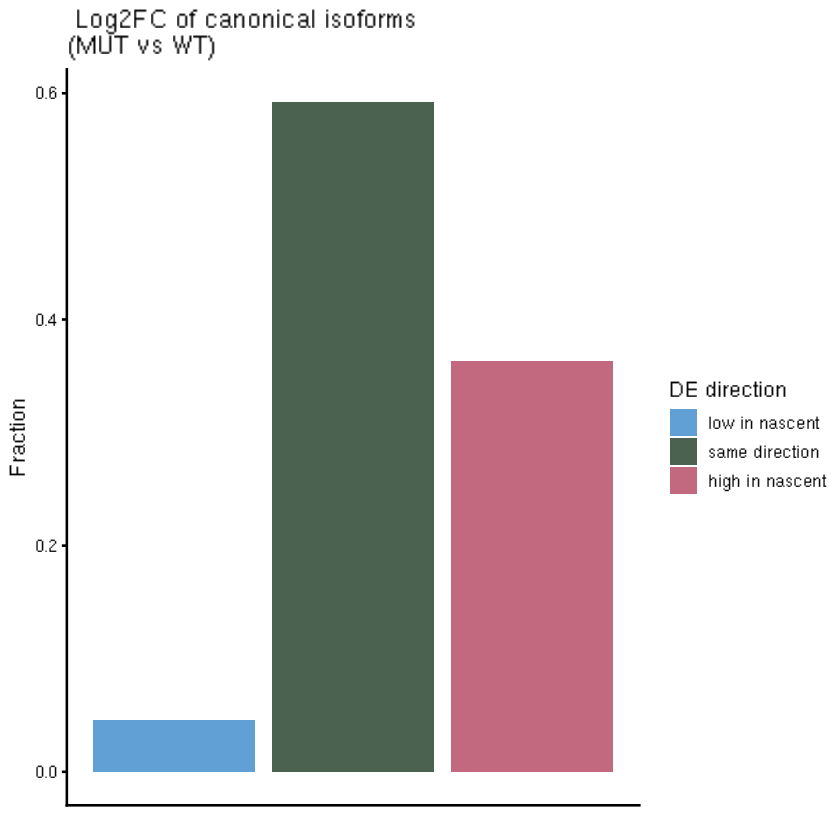

In [198]:
df_merged %>% 
    filter(label != 'missing', feature_id == 'canonical') %>% 
    count(label) %>% mutate(frac = n / nrow(df_merged %>% filter(label != 'missing', feature_id == 'canonical'))) %>% 
    ggplot(aes(x = label, y = frac, fill = label))+
    geom_bar(stat = "identity") +
    scale_fill_manual(values = match_colors) +
    labs(x = "", y = "Fraction", fill = "DE direction", title =" Log2FC of canonical isoforms\n(MUT vs WT)") +
    theme(axis.text.x = element_blank(), axis.ticks.x = element_blank())

ggsave("../figures/12_correlation_log2fc_nascent_vs_mature_by_match_canonical_fraction.pdf", width = 4, height = 3)

In [ ]:
fit <- lm(Teloprime ~ Nascent, data = wt_tpm)
summary_fit <- summary(fit)

slope <- coef(summary_fit)[2]
intercept <- coef(summary_fit)[1]

form = paste0('Nascent = ', round(intercept, 3), '+',  round(slope, 3), "xTeloprime")

wt_tpm %>% 
    ggplot(aes(x = Teloprime, y = Nascent)) +
    # geom_point(size = 1, alpha = 0.8) +
    scale_color_manual(values = c("up in nascent" = "#d7191c", "down in nascent" = "#2b83ba", "not sig" = "#969696")) +
    theme_bw(base_size = 14) +
    labs(x = "Teloprime (Log2TPM)", y = "Nascent (Log2TPM)", title = paste0("Average expression in WT\n", form)) +
    geom_bin2d(bins = 70) +
    geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "black") +
    scale_fill_continuous(type = "viridis") +
    xlim(0, 16) + ylim(0, 16)

## calculate RNAPII processivity index

In [180]:
nascent_q_cov<- read.table("/private/groups/brookslab/gabai/projects/yeastMeth/data/rna/nascentRNA/riboPool/pausing/251201_gene_quantile_cov_table_gene_quantile_coverage_table.tsv", 
                       sep = "\t", header = T)

sample_level = paste0(rep(c("WT", "MUT"), each = 2), '_', rep(c("rep1", "rep2"), 2))

df<- nascent_q_cov %>% 
    mutate(gene_id = str_extract(Gene_Quantile, ".*(?=_Q)"), Q = str_extract(Gene_Quantile, "(?<=_Q)\\d+")) %>%
    pivot_longer(cols = c(WT_rep1, WT_rep2, MUT_rep1, MUT_rep2),
               names_to = "sample",
               values_to = "count") %>% 
    mutate(sample = factor(sample, levels = sample_level)) %>% 
    filter(gene_id %in% final_iso_tb$gene_id)

# check all Q present in all genes in all samples
dim(df)[1] == (length(df$gene_id %>% sort() %>% unique())*4*7)

# remove genes with no reads in Q1
no_expr<-df %>% filter(Q == 1) %>% filter(count < 10) %>% pull(gene_id) %>% sort() %>% unique()
df <- df %>% filter(!gene_id %in% no_expr)

length(sort(unique(df$gene_id)))

dim(df)[1] == (length(df$gene_id %>% sort() %>% unique())*4*7)

df <- df %>% 
    left_join(df %>% group_by(gene_id, sample) %>% summarise(total_c = max(count), .groups = "drop"), by = c("gene_id", "sample")) %>%
    mutate(frac = (count / total_c))

[1] TRUE

[1] 3251

[1] TRUE

In [176]:
pause_df<- df %>% 
    filter(Q != 1) %>% 
    group_by(sample, gene_id) %>% 
    summarize(pause = mean(frac), .groups = "drop") %>% 
    pivot_wider(names_from = sample, values_from = pause) %>% 
    mutate(
        WT_ave  = rowMeans(across(c(WT_rep1, WT_rep2)), na.rm = TRUE),
        MUT_ave = rowMeans(across(c(MUT_rep1, MUT_rep2)), na.rm = TRUE)
    ) %>% 
    mutate(delta_pause = MUT_ave - WT_ave)  %>% arrange(gene_id)

write.table(pause_df, "../data/12_RNAPII_processivity_index.tsv", sep = "\t", col.names = T, row.names = F, quote = FALSE)

## Compare pausing index between grouops

In [178]:
pause_df<- read.table("../data/12_RNAPII_processivity_index.tsv", header = T, sep = "\t")

In [268]:
df_canonical<- df_merged %>% filter(feature_id == 'canonical')
pause_df$label = df_canonical[match(pause_df$gene_id, df_canonical$gene_id), "label"]

pause_df$class = final_iso_tb[match(pause_df$gene_id, final_iso_tb$gene_id), "class"]
pause_df$class<- factor(pause_df$class, levels = c('low', 'medium', 'high'))

In [181]:
# between de direction class

Warning message:
“Removed 43 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 43 rows containing non-finite outside the scale range (`stat_signif()`).”
Warning message:
“Removed 43 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 43 rows containing non-finite outside the scale range (`stat_signif()`).”


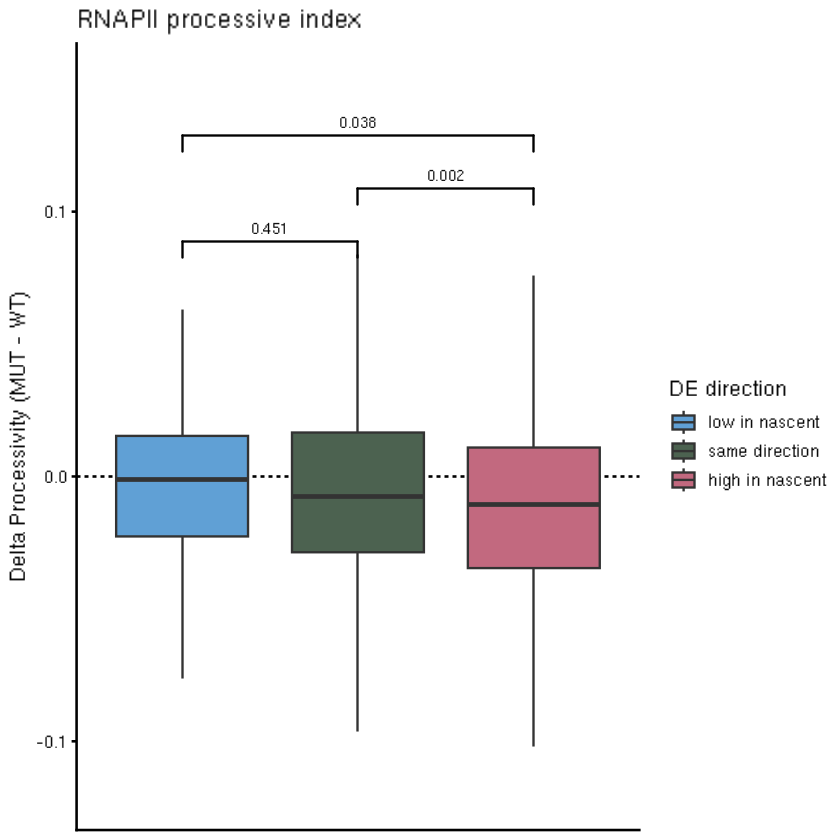

In [280]:
comparisons <- list(
    c("low in nascent", "same direction"),
    c("same direction", "high in nascent"),
    c("low in nascent", "high in nascent")
)

pvals <- map_dfr(comparisons, function(g) {
    x <- pause_df %>% filter(label == g[1], !is.na(delta_pause)) %>% pull(delta_pause)
    y <- pause_df %>% filter(label == g[2], !is.na(delta_pause)) %>% pull(delta_pause)
    test <- wilcox.test(x, y)
    tibble(group1 = g[1], group2 = g[2], p.value = test$p.value, p.format = scales::pvalue(test$p.value, accuracy =0.001))
})

pause_df %>% 
    filter(!is.na(label), label != "missing") %>% 
    ggplot(aes(x = label, y = delta_pause, fill = label)) +
    geom_hline(yintercept = 0, linetype = "dashed", color = "black") +
    geom_boxplot(outlier.shape = NA, alpha = 1, size = 0.5) +
    labs(x = "Sample", y = "Delta Processivity (MUT - WT)", title = "RNAPII processive index", fill = "DE direction") +
    scale_x_discrete(labels = NULL) +
    theme(axis.ticks.x = element_blank(), axis.title.x = element_blank()) +
    geom_signif(
        comparisons = comparisons,
        annotations = pvals$p.format,
        y_position  = c(0.06, 0.08, 0.1),
        tip_length  = 0.01,
        textsize    = 3
    ) +
    scale_fill_manual(values = match_colors) + 
    ylim(-0.12, 0.15)

ggsave("../figures/Supp_processivity_by_match_between_nascent_teloprime_no_missing.pdf", width = 4, height = 3)

Warning message:
“Removed 20 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 20 rows containing non-finite outside the scale range (`stat_signif()`).”
Warning message:
“Removed 20 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 20 rows containing non-finite outside the scale range (`stat_signif()`).”


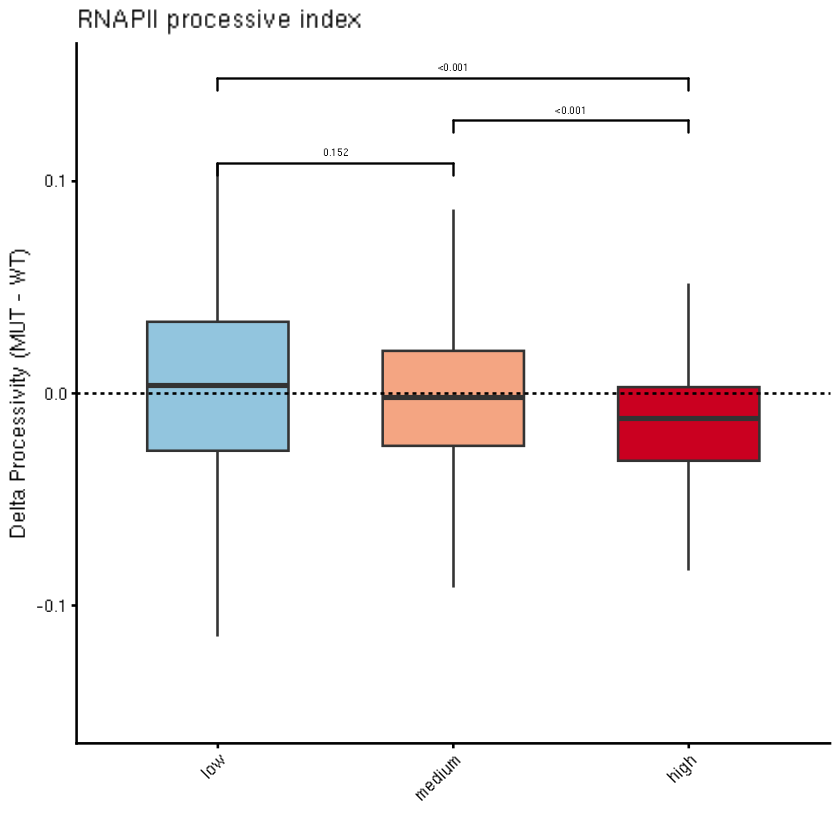

In [304]:
comparisons = list(c("low", "medium"),
                   c("medium", "high"),
                   c("low", "high"))

pvals <- map_dfr(comparisons, function(g) {
    x <- pause_df %>% filter(class == g[1], !is.na(delta_pause)) %>% pull(delta_pause)
    y <- pause_df %>% filter(class == g[2], !is.na(delta_pause)) %>% pull(delta_pause)
    test <- wilcox.test(x, y)
    tibble(group1 = g[1], group2 = g[2], p.value = test$p.value, p.format = scales::pvalue(test$p.value, accuracy =0.001))
})

mcol <- rev(c("#ca0020", "#f4a582", "#92c5de"))
names(mcol) <- c("low", "medium", "high")

pause_df %>% 
    ggplot(aes(x = class, y = delta_pause, fill = class)) +
    geom_boxplot(outlier.shape = NA, width = 0.6) +
    geom_hline(yintercept = 0,  linetype = "dashed", color = "black") +
    labs(x = "", y = "Delta Processivity (MUT - WT)", title = "RNAPII processive index") +
        geom_signif(
        comparisons = comparisons,
        annotations = pvals$p.format,
        y_position  = c(0.08, 0.1, 0.12),
        tip_length  = 0.01,
        textsize    = 2
    ) +
    scale_fill_manual(values = mcol) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1), legend.position = "none") +
    ylim(-0.15, 0.15)

ggsave("../figures/Supp_processivity_by_class.pdf", width = 3.5, height = 3.5)

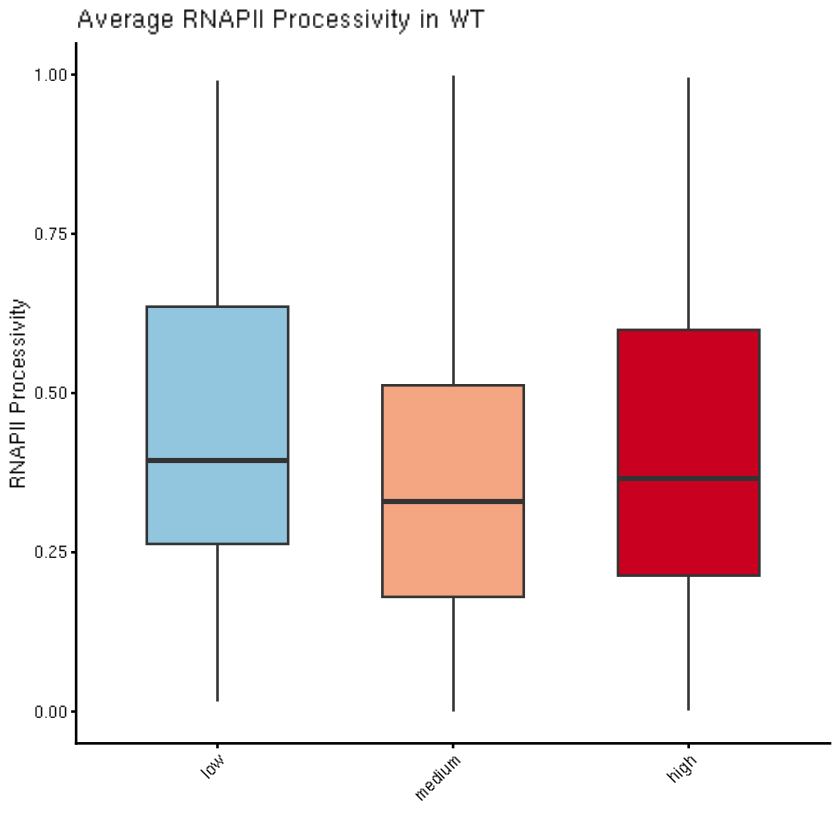

In [305]:
comparisons = list(c("low", "medium"),
                   c("medium", "high"),
                   c("low", "high"))

pvals <- map_dfr(comparisons, function(g) {
    x <- pause_df %>% filter(class == g[1], !is.na(delta_pause)) %>% pull(delta_pause)
    y <- pause_df %>% filter(class == g[2], !is.na(delta_pause)) %>% pull(delta_pause)
    test <- wilcox.test(x, y)
    tibble(group1 = g[1], group2 = g[2], p.value = test$p.value, p.format = scales::pvalue(test$p.value, accuracy =0.001))
})


mcol <- rev(c("#ca0020", "#f4a582", "#92c5de"))
names(mcol) <- c("low", "medium", "high")

pause_df %>% 
    ggplot(aes(x = class, y = WT_ave, fill = class)) +
    geom_boxplot(outlier.shape = NA, width = 0.6) +
    scale_fill_manual(values = mcol) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1), legend.position = "none") +
    labs(x = "", y = "RNAPII Processivity", title = "Average RNAPII Processivity in WT")

ggsave("../figures/Supp_WT_average_processivity_by_class.pdf", width = 3.5, height = 3.5)

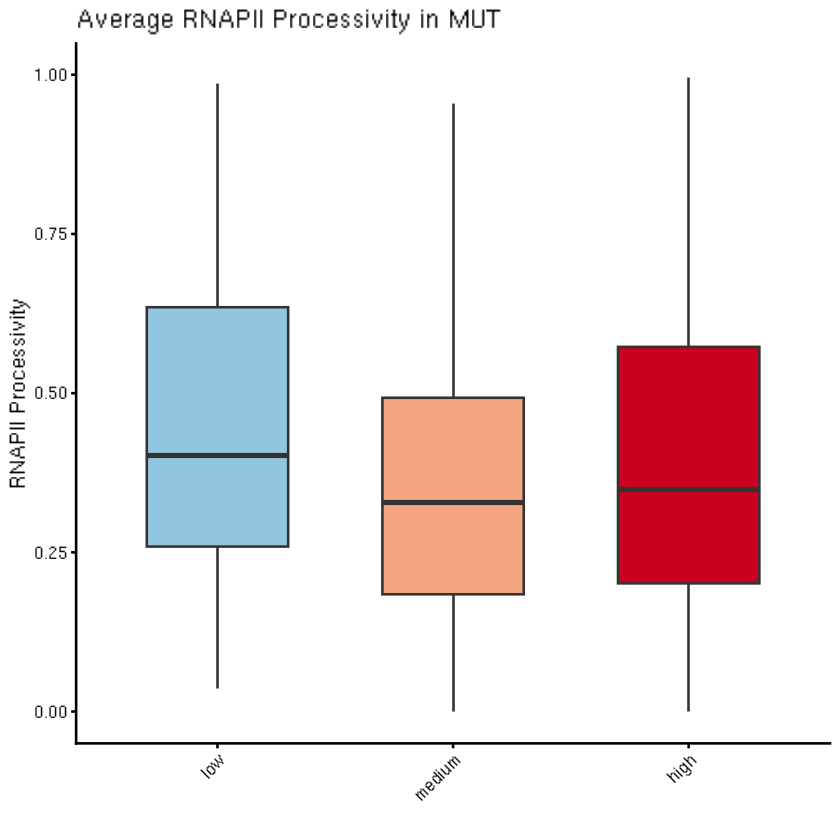

In [306]:
comparisons = list(c("low", "medium"),
                   c("medium", "high"),
                   c("low", "high"))

pvals <- map_dfr(comparisons, function(g) {
    x <- pause_df %>% filter(class == g[1], !is.na(delta_pause)) %>% pull(delta_pause)
    y <- pause_df %>% filter(class == g[2], !is.na(delta_pause)) %>% pull(delta_pause)
    test <- wilcox.test(x, y)
    tibble(group1 = g[1], group2 = g[2], p.value = test$p.value, p.format = scales::pvalue(test$p.value, accuracy =0.001))
})


mcol <- rev(c("#ca0020", "#f4a582", "#92c5de"))
names(mcol) <- c("low", "medium", "high")

pause_df %>% 
    ggplot(aes(x = class, y = MUT_ave, fill = class)) +
    geom_boxplot(outlier.shape = NA, width = 0.6) +
    scale_fill_manual(values = mcol) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1), legend.position = "none") +
    labs(x = "", y = "RNAPII Processivity", title = "Average RNAPII Processivity in MUT")

ggsave("../figures/Supp_MUT_average_processivity_by_class.pdf", width = 3.5, height = 3.5)